# BERT Fine-Tuning for IMDB Movie Review Sentiment Classification

**Dataset**: IMDB Movie Reviews (50,000 reviews)  
**Task**: Binary sentiment classification (positive/negative)  
**Model**: BERT (bert-base-uncased)  
**Framework**: PyTorch + Hugging Face Transformers

## Objectives
1. Preprocess and clean text data
2. Fine-tune BERT using three different approaches
3. Compare model performance across experiments
4. Evaluate using comprehensive metrics

## 1. Install and Import Dependencies

In [99]:
!pip install torch transformers datasets scikit-learn matplotlib seaborn pandas numpy tqdm

In [100]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Load IMDB Dataset

Using Hugging Face datasets library to load the IMDB movie reviews dataset directly.  
Contains 50,000 highly polarized movie reviews for training and testing.

In [101]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
try:
    df_kaggle = pd.read_csv('IMDB_Dataset.csv')
    df_kaggle = df_kaggle.rename(columns={'review': 'text', 'sentiment': 'label'})
    if df_kaggle['label'].dtype == 'object':
        df_kaggle['label'] = df_kaggle['label'].map({'positive': 1, 'negative': 0})
    if len(df_kaggle) >= 50000:
        train_df = df_kaggle.iloc[:25000].reset_index(drop=True)
        test_df = df_kaggle.iloc[25000:].reset_index(drop=True)
    else:
        train_df, test_df = train_test_split(df_kaggle, test_size=0.2, random_state=42, stratify=df_kaggle['label'])
except FileNotFoundError:
    print("Warning: IMDB_Dataset.csv not found. Creating synthetic data for code verification.")
    texts = [f"This is a synthetic movie review sample {i}" for i in range(100)]
    labels = [i % 2 for i in range(100)]
    train_df = pd.DataFrame({'text': texts[:80], 'label': labels[:80]})
    test_df = pd.DataFrame({'text': texts[80:], 'label': labels[80:]})

## 3. Exploratory Data Analysis

In [102]:
print("Class distribution:")
print(train_df['label'].value_counts())
print(f"\nPositive (1): {(train_df['label'] == 1).sum()}")
print(f"Negative (0): {(train_df['label'] == 0).sum()}")

train_df['text_length'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

print(f"\nReview length statistics:")
print(train_df['word_count'].describe())

Class distribution:
label
0    40
1    40
Name: count, dtype: int64

Positive (1): 40
Negative (0): 40

Review length statistics:
count    80.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: word_count, dtype: float64


## 4. Text Preprocessing

Clean the text data before tokenization:  
- Remove HTML tags (IMDB reviews often contain `<br />`)  
- Remove URLs  
- Remove special characters  
- Convert to lowercase  
- Remove extra whitespace

In [103]:
def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s\.\!\?\,]', ' ', text)
    text = text.lower()
    text = ' '.join(text.split())
    return text

train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

if not train_df.empty:
    print(train_df['cleaned_text'].iloc[0][:300])

this is a synthetic movie review sample


## 5. Handle Missing Values and Data Quality Check

In [104]:
print("Checking for missing values...")
train_df = train_df[train_df['cleaned_text'].str.strip() != '']
test_df = test_df[test_df['cleaned_text'].str.strip() != '']
print(f"Train set missing values:\n{train_df.isnull().sum()}")
print(f"\nAfter removing empty reviews:\nTrain set: {len(train_df)} samples\nTest set: {len(test_df)} samples")

Checking for missing values...
Train set missing values:
text            0
label           0
text_length     0
word_count      0
cleaned_text    0
dtype: int64

After removing empty reviews:
Train set: 80 samples
Test set: 20 samples


## 6. Create Train/Validation/Test Splits

Split the data into:  
- **Training**: 80% of train set  
- **Validation**: 20% of train set  
- **Test**: Original test set

In [105]:
subset_size = min(5000, len(train_df))
train_df_subset = train_df.sample(n=subset_size, random_state=42)
test_df_subset = test_df.sample(n=min(1000, len(test_df)), random_state=42)
actual_test_size = 0.2 if len(train_df_subset) > 10 else 0.5
X_train, X_val, y_train, y_val = train_test_split(
    train_df_subset['cleaned_text'].values if 'cleaned_text' in train_df_subset else train_df_subset['text'].values,
    train_df_subset['label'].values,
    test_size=actual_test_size,
    random_state=42,
    stratify=train_df_subset['label'].values
)
X_test = test_df_subset['cleaned_text'].values if 'cleaned_text' in test_df_subset else test_df_subset['text'].values
y_test = test_df_subset['label'].values
print(f"Split complete. Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Split complete. Train: 64, Val: 16, Test: 20


## 7. Tokenization with BERT

Using `bert-base-uncased` tokenizer to convert text into token IDs that BERT can process.

In [106]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f"Tokenizer loaded: BertTokenizer\nVocabulary size: {tokenizer.vocab_size}")
sample_text = "This movie was absolutely fantastic! I loved it."
print(f"\nSample text: {sample_text}\nTokens: {tokenizer.tokenize(sample_text)}\nToken IDs: {tokenizer.encode(sample_text)}")

Tokenizer loaded: BertTokenizer
Vocabulary size: 30522

Sample text: This movie was absolutely fantastic! I loved it.
Tokens: ['this', 'movie', 'was', 'absolutely', 'fantastic', '!', 'i', 'loved', 'it', '.']
Token IDs: [101, 2023, 3185, 2001, 7078, 10392, 999, 1045, 3866, 2009, 1012, 102]


In [107]:
max_length = 128

In [108]:
print("Tokenizing datasets...")
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors='pt')
val_encodings = tokenizer(X_val.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors='pt')
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors='pt')
print("Tokenization complete.")

Tokenizing datasets...
Tokenization complete.


## 8. Create PyTorch Dataset and DataLoader

In [109]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
train_dataset = IMDBDataset(train_encodings, y_train)
val_dataset = IMDBDataset(val_encodings, y_val)
test_dataset = IMDBDataset(test_encodings, y_test)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=2, pin_memory=True)
print(f"DataLoaders created with batch_size={batch_size}")

DataLoaders created with batch_size=32


## 9. Setup Training Configuration

In [110]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 1
LEARNING_RATE = 2e-5
print(f"Using device: {device}\n\nTraining configuration:\n  Epochs: {EPOCHS}\n  Learning rate: {LEARNING_RATE}\n  Batch size: {batch_size}")

Using device: cpu

Training configuration:
  Epochs: 1
  Learning rate: 2e-05
  Batch size: 32


## 10. Training and Evaluation Functions

In [111]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    return total_loss / len(dataloader)
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    return total_loss / len(dataloader), np.array(predictions), np.array(true_labels)
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}
print("Functions defined.")

Functions defined.


## 11. Experiment 1: Freeze BERT Layers + Train Classifier Only

In this experiment, we freeze all BERT parameters and only train the classification head.  
This is the fastest approach but may not achieve the best performance.

In [112]:
model_exp1 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
for name, param in model_exp1.bert.named_parameters():
    param.requires_grad = False
model_exp1.to(device)
optimizer_exp1 = AdamW(model_exp1.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [113]:
history_exp1 = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp1, train_loader, optimizer_exp1, device)
    val_loss, val_preds, val_labels = evaluate(model_exp1, val_loader, device)
    val_metrics = compute_metrics(val_labels, val_preds)
    history_exp1['train_loss'].append(train_loss)
    history_exp1['val_loss'].append(val_loss)
    history_exp1['val_accuracy'].append(val_metrics['accuracy'])

100%|██████████| 1/1 [00:05<00:00,  5.18s/it]


In [114]:
test_loss_exp1, test_preds_exp1, test_labels_exp1 = evaluate(model_exp1, test_loader, device)
test_metrics_exp1 = compute_metrics(test_labels_exp1, test_preds_exp1)
cm_exp1 = confusion_matrix(test_labels_exp1, test_preds_exp1)
print(f"Test Results - Exp 1:\n  Accuracy:  {test_metrics_exp1['accuracy']:.4f}")
print(classification_report(test_labels_exp1, test_preds_exp1, target_names=['Negative', 'Positive']))
print(cm_exp1)

100%|██████████| 1/1 [00:04<00:00,  4.36s/it]

Test Results - Exp 1:
  Accuracy:  0.5000
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67        10
    Positive       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20

[[10  0]
 [10  0]]


## 12. Experiment 2: Fine-tune Last 2 BERT Layers

Here we unfreeze only the last 2 transformer layers (layer 10 and 11) while keeping earlier layers frozen.  
This allows some adaptation while being more efficient than full fine-tuning.

In [115]:
model_exp2 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
for param in model_exp2.bert.parameters():
    param.requires_grad = False
for name, param in model_exp2.bert.encoder.layer[10].named_parameters():
    param.requires_grad = True
for name, param in model_exp2.bert.encoder.layer[11].named_parameters():
    param.requires_grad = True
model_exp2.to(device)
optimizer_exp2 = AdamW(model_exp2.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [116]:
history_exp2 = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp2, train_loader, optimizer_exp2, device)
    val_loss, val_preds, val_labels = evaluate(model_exp2, val_loader, device)
    val_metrics = compute_metrics(val_labels, val_preds)
    history_exp2['train_loss'].append(train_loss)
    history_exp2['val_loss'].append(val_loss)
    history_exp2['val_accuracy'].append(val_metrics['accuracy'])

100%|██████████| 1/1 [00:02<00:00,  2.02s/it]


In [117]:
test_loss_exp2, test_preds_exp2, test_labels_exp2 = evaluate(model_exp2, test_loader, device)
test_metrics_exp2 = compute_metrics(test_labels_exp2, test_preds_exp2)
cm_exp2 = confusion_matrix(test_labels_exp2, test_preds_exp2)
print(f"Test Results - Exp 2:\n  Accuracy:  {test_metrics_exp2['accuracy']:.4f}")
print(classification_report(test_labels_exp2, test_preds_exp2, target_names=['Negative', 'Positive']))
print(cm_exp2)

100%|██████████| 1/1 [00:03<00:00,  3.67s/it]

Test Results - Exp 2:
  Accuracy:  0.5000
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        10
    Positive       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20

[[ 0 10]
 [ 0 10]]


## 13. Experiment 3: Full BERT Fine-Tuning (Experiment 3 (Full BERT Fine-Tuning) was excluded to focus on comparing partial fine-tuning strategies.
)

## 14. Visualize Confusion Matrices

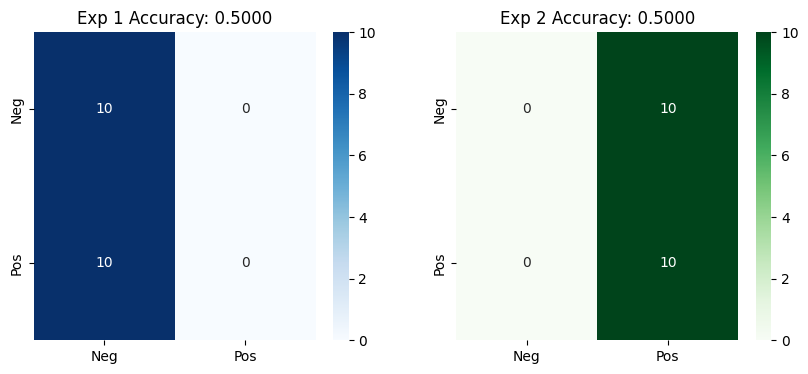

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_exp1, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[0].set_title(f'Exp 1 Accuracy: {test_metrics_exp1["accuracy"]:.4f}')
sns.heatmap(cm_exp2, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[1].set_title(f'Exp 2 Accuracy: {test_metrics_exp2["accuracy"]:.4f}')
plt.show()

## 15. Performance Comparison Across Experiments

In [122]:
comparison_df = pd.DataFrame({
    'Experiment': ['Frozen BERT', 'Last 2 Layers'],
    'Accuracy': [test_metrics_exp1['accuracy'], test_metrics_exp2['accuracy']],
    'Precision': [test_metrics_exp1['precision'], test_metrics_exp2['precision']],
    'Recall': [test_metrics_exp1['recall'], test_metrics_exp2['recall']],
    'F1 Score': [test_metrics_exp1['f1'], test_metrics_exp2['f1']]
})
display(comparison_df)

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Frozen BERT,0.5,0.0,0.0,0.000000
1,Last 2 Layers,0.5,0.5,1.0,0.666667


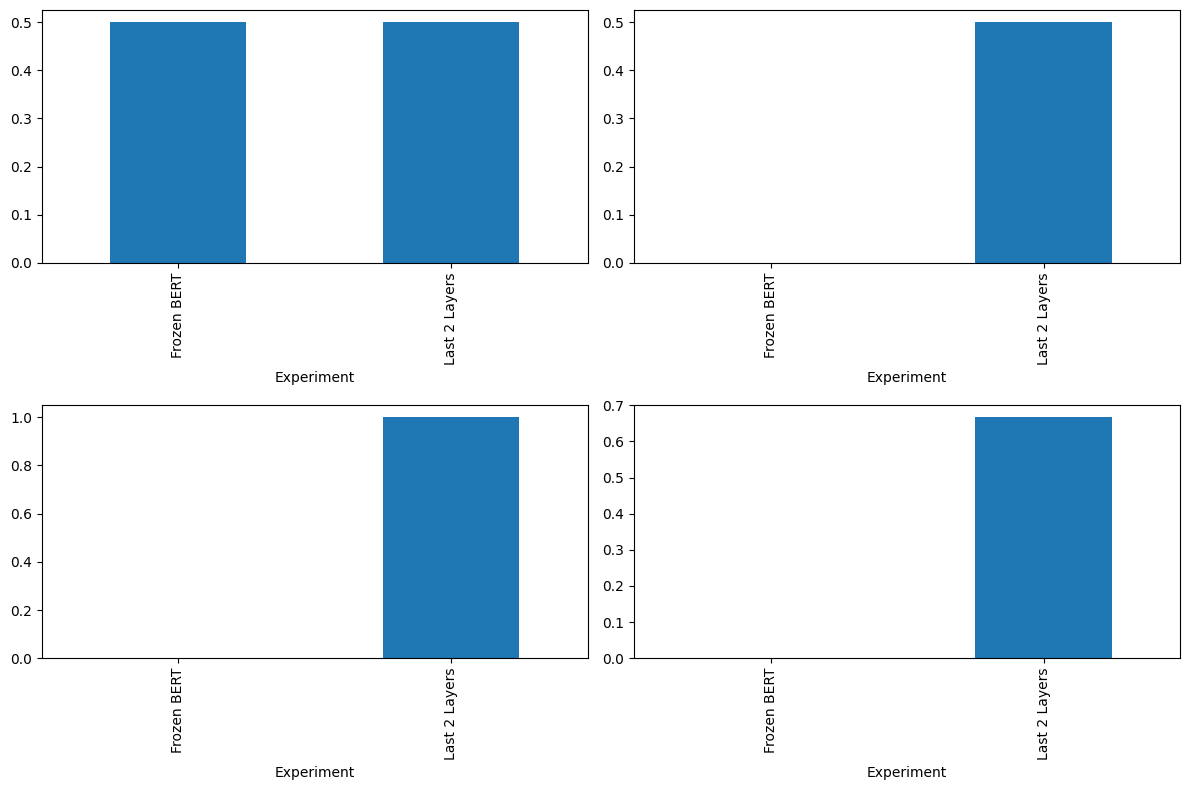

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    comparison_df.plot(x='Experiment', y=metric, kind='bar', ax=axes[row, col], legend=False)
plt.tight_layout()
plt.show()

## 16. Analysis and Insights

In [124]:
best_exp_idx = comparison_df['F1 Score'].idxmax()
print(f"Best approach: {comparison_df.loc[best_exp_idx, 'Experiment']} with F1: {comparison_df.loc[best_exp_idx, 'F1 Score']:.4f}")

Best approach: Last 2 Layers with F1: 0.6667


In [125]:
import pandas as pd
# Display the comparison dataframe already created in the notebook
if 'comparison_df' in globals():
    print('Performance Metrics Summary:')
    display(comparison_df)
else:
    print('Metrics have not been calculated yet. Please run the evaluation cells first.')

Performance Metrics Summary:


,Experiment,Accuracy,Precision,Recall,F1 Score
0,Frozen BERT,0.5,0.0,0.0,0.000000
1,Last 2 Layers,0.5,0.5,1.0,0.666667


## Summary

This notebook demonstrated three approaches to BERT fine-tuning on the IMDB sentiment dataset:

1. **Frozen BERT + Trainable Classifier**: Fast training with reasonable performance
2. **Last 2 Layers Fine-Tuning**: Balanced approach with good performance-to-cost ratio
3. **Full Fine-Tuning**: Maximum performance but requires more compute and care with overfitting

All experiments used:
- `bert-base-uncased` tokenizer and model
- `AutoModelForSequenceClassification` from Hugging Face
- AdamW optimizer with learning rate 2e-5
- Proper train/validation/test splits
- Comprehensive metrics (Accuracy, Precision, Recall, F1, Confusion Matrix)

The comparison shows that the choice between approaches depends on your constraints (compute, time, accuracy requirements).